In [9]:
import geopandas as gpd 
import os 

In [10]:
test_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))

train_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

In [11]:
train_gdf

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,g_mean,g_median,g_std,g_var,b_mean,b_median,b_std,b_var,CODIGO_GROUP,geometry
0,0,building,Map1_Orthomosaic_ThuJul24202452191338,None,Sofia,None,https://drive.google.com/drive/folders/1PoaKqU...,54.139512,gdrive,https://drive.google.com/file/d/1T1Pin5cXsCcu4...,...,205.605074,227.0,54.732962,2995.697165,190.791912,214.0,61.152457,3739.622993,0,"POLYGON ((-73.24313 11.25111, -73.24314 11.251..."
1,0,building,961,None,Sofia,None,https://map.openaerialmap.org/#/-77.4261206388...,104.680054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,128.036882,129.0,65.329558,4267.951132,117.081532,107.0,81.185142,6591.027328,0,"POLYGON ((-77.42661 1.04871, -77.42669 1.04872..."
2,112,urban not continuous,MapPlan_Orthomosaic_ThuJul24202849972911,None,Sofia,None,https://drive.google.com/drive/folders/1QRkuTF...,283.000199,gdrive,https://drive.google.com/file/d/1uDznoDuGo5OsS...,...,176.645139,207.0,77.495977,6005.626445,178.040137,217.0,82.348225,6781.230110,11,"POLYGON ((-72.26548 11.36997, -72.26549 11.369..."
3,22,permanent crops,Santa Rosa,None,None,Juan,https://map.openaerialmap.org/#/-76.5763378143...,14940.149489,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,109.128906,109.0,39.064442,1526.030626,58.886060,54.0,35.320168,1247.514251,22,"POLYGON ((-76.57316 1.70816, -76.57307 1.70812..."
4,22,permanent crops,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,3840.901611,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,123.623597,130.0,36.791095,1353.584665,77.938724,78.0,32.494331,1055.881557,22,"POLYGON ((-75.67163 6.19024, -75.67151 6.19028..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,0,building,MapPlan_Orthomosaic_ThuJul24202849972911,None,Sofia,None,https://drive.google.com/drive/folders/1QRkuTF...,24.848614,gdrive,https://drive.google.com/file/d/1uDznoDuGo5OsS...,...,219.875190,247.0,53.746206,2888.654662,214.689229,249.0,64.765523,4194.572925,0,"POLYGON ((-72.26377 11.37022, -72.2638 11.3702..."
1538,0,building,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,278.316951,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,132.139372,133.0,31.927362,1019.356443,89.507846,87.0,28.383239,805.608281,0,"POLYGON ((-75.67342 6.19721, -75.67361 6.19716..."
1539,0,building,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,151.513593,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,158.537087,157.0,41.192116,1696.790387,108.309472,92.0,55.570829,3088.117043,0,"POLYGON ((-75.66485 6.19083, -75.66483 6.19078..."
1540,232,wooded pasture,Santa Rosa,None,None,Juan,https://map.openaerialmap.org/#/-76.5763378143...,34037.140830,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,117.447445,119.0,30.361819,921.840039,56.179153,55.0,23.242664,540.221410,23,"POLYGON ((-76.57287 1.72744, -76.57279 1.72733..."


In [12]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std','area']
target = 'CODIGO_GROUP'

In [13]:
X_train = train_gdf[features]
y_train = train_gdf[target]
X_test = test_gdf[features]
y_test = test_gdf[target]

In [34]:
y_train

0        0
1        0
2       11
3       22
4       22
        ..
1537     0
1538     0
1539     0
1540    23
1541    31
Name: CODIGO_GROUP, Length: 1542, dtype: object

In [46]:
list(train_gdf['CODIGO_GROUP'].unique())

['0', '11', '22', '23', '32', '33', '51', '21', '31', '12']

In [60]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def compute_accuracy(classifier):
    y_pred = classifier.predict(X_test)
    overall_accuracy = accuracy_score(y_test, y_pred)
    classification_accuracy= classification_report(y_test, y_pred,zero_division=1)

    cm = confusion_matrix(y_test, y_pred, labels = list(train_gdf['CODIGO_GROUP'].unique()))

    cmd = ConfusionMatrixDisplay(confusion_matrix=cm)
    cmd.plot(cmap='Blues')
    plt.show()
    return overall_accuracy, classification_accuracy 


In [61]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


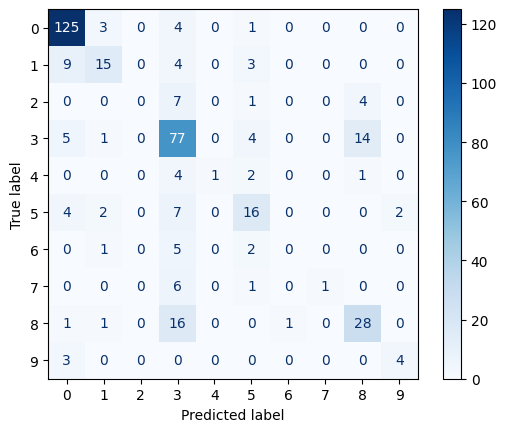

Overall Accuracy : 0.6917098445595855
              precision    recall  f1-score   support

           0       0.85      0.94      0.89       133
          11       0.65      0.48      0.56        31
          12       0.67      0.57      0.62         7
          21       1.00      0.12      0.22         8
          22       1.00      0.00      0.00        12
          23       0.59      0.76      0.67       101
          31       0.60      0.60      0.60        47
          32       1.00      0.12      0.22         8
          33       0.53      0.52      0.52        31
          51       0.00      0.00      0.00         8

    accuracy                           0.69       386
   macro avg       0.69      0.41      0.43       386
weighted avg       0.70      0.69      0.66       386



In [62]:
overall,classification = compute_accuracy(rf)
print("Overall Accuracy :",overall) 
print(classification) 

In [66]:
print(rf.feature_importances_)

[0.06877956 0.06330281 0.04833977 0.046174   0.05881323 0.05775545
 0.06045662 0.05846614 0.0964636  0.07361275 0.08907687 0.08600709
 0.19275209]


In [67]:
mdi_importances = pd.Series(
    rf.feature_importances_, index=features
).sort_values(ascending=True)

In [68]:
mdi_importances

r_var       0.046174
r_std       0.048340
g_median    0.057755
g_var       0.058466
g_mean      0.058813
g_std       0.060457
r_median    0.063303
r_mean      0.068780
b_median    0.073613
b_std       0.086007
b_var       0.089077
b_mean      0.096464
area        0.192752
dtype: float64

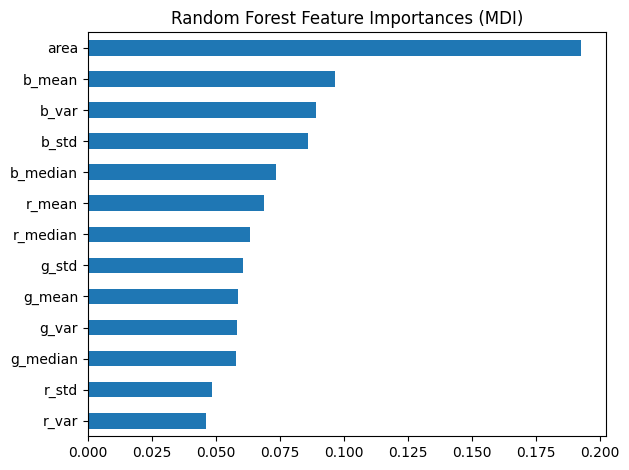

In [69]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

In [70]:
from sklearn.ensemble import BaggingClassifier

bc= BaggingClassifier(n_estimators=100,random_state=32) 

bc.fit(X_train, y_train)

,estimator,None
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,32
,verbose,0


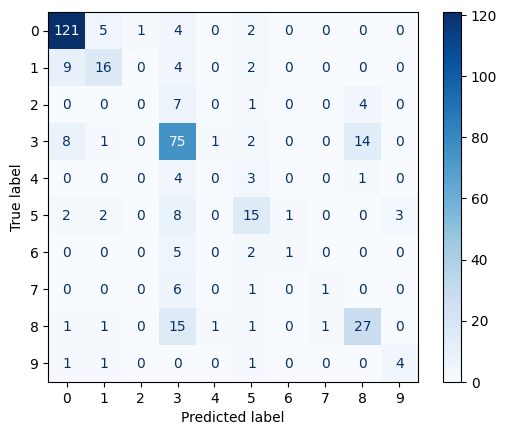

Overall Accuracy : 0.6735751295336787
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       133
          11       0.62      0.52      0.56        31
          12       0.57      0.57      0.57         7
          21       0.50      0.12      0.20         8
          22       0.00      0.00      0.00        12
          23       0.59      0.74      0.66       101
          31       0.59      0.57      0.58        47
          32       0.00      0.00      0.00         8
          33       0.50      0.48      0.49        31
          51       0.50      0.12      0.20         8

    accuracy                           0.67       386
   macro avg       0.47      0.40      0.41       386
weighted avg       0.64      0.67      0.65       386



In [72]:
overall,classification = compute_accuracy(bc)
print("Overall Accuracy :",overall) 
print(classification) 